<a href="https://colab.research.google.com/github/SKS1401/MLProject-Early_Stroke_Risk_Prediction_System/blob/main/Early_Stroke_Risk_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Day-1

###Loading the Dataset

In [26]:
import pandas as pd
import numpy as np
dataset=pd.read_csv("healthcare-dataset-stroke-data.csv")
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


###Exploratory Data Analysis

In [27]:
dataset.shape

(5110, 12)

In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [29]:
dataset.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [30]:
dataset['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [31]:
dataset=dataset.drop(columns=['id'])

###Handling NaN values in BMI Column

In [32]:
median_of_bmi_col=dataset['bmi'].median()
dataset['bmi']=dataset['bmi'].replace(np.nan,median_of_bmi_col)
dataset.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


###Creating Heatmap

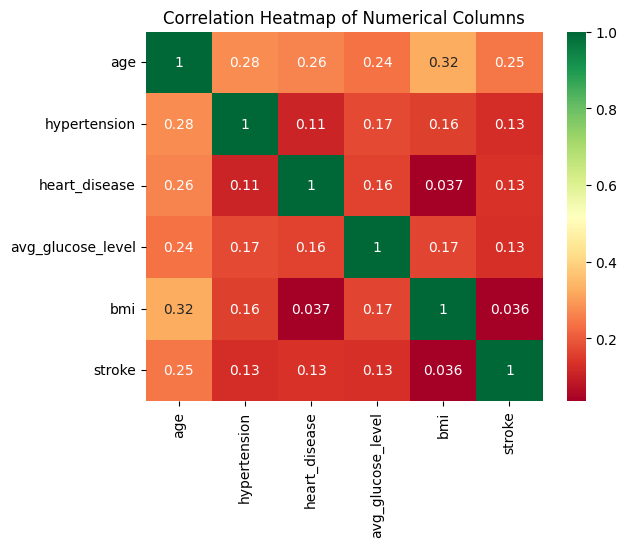

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_dataset = dataset.select_dtypes(include=['number'])
heatmap_plot=sns.heatmap(numeric_dataset.corr(),annot=True,cmap='RdYlGn')
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

##Day-2

###Preparing the OneHotEncoder

In [34]:
#Here categorical columns are gender,ever_married,work_type,residence_type,smoking_status
#hypertension,heart_disease are already encoded,so no need to convert this
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_cols=['gender','ever_married','work_type','Residence_type','smoking_status']
numerical_cols=['age','hypertension','heart_disease','avg_glucose_level','bmi']
ct=ColumnTransformer(transformers=[
    ("cat",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),categorical_cols),
    ("num","passthrough",numerical_cols)
])

###Creating a matrix of the features and the dependent variable vector

In [35]:
X=dataset.drop(columns=['stroke'])
y=dataset['stroke']


###Splitting the dataset into training set and test set

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


###Applying Encoding

In [37]:
X_train=ct.fit_transform(X_train)
X_test=ct.transform(X_test)

###Applying SMOTE

In [38]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)


In [39]:
y_train.value_counts()

,count
stroke,
0,3889
1,199


In [40]:
y_train_sm.value_counts()

,count
stroke,
0,3889
1,3889


###Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train_sm)
X_test_scaled=scaler.transform(X_test)

##Day 3

###Training the Random Forest model (on SMOTE-balanced data)

In [42]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=500,random_state=42)
classifier.fit(X_train_scaled,y_train_sm)

RandomForestClassifier(n_estimators=500, random_state=42)

###Predicting the test set results

In [43]:
y_pred=classifier.predict(X_test_scaled)
print(y_pred)

[0 0 0 ... 0 0 0]


###Model Evaluation

####Confusion Matrix

In [44]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[962  10]
 [ 48   2]]


####Accuracy Score

In [45]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)
print(score)

0.9432485322896281


####Sensitivity and Specificity

In [46]:
y_prob = classifier.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.3).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Sensitivity:", tp/(tp+fn))
print("Specificity:", tn/(tn+fp))

Sensitivity: 0.16
Specificity: 0.9650205761316872


####Improving Sensitivity

In [47]:
y_prob = classifier.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.4, 0.3, 0.2, 0.1]:
    y_pred_new = (y_prob >= threshold).astype(int)
    cm_new = confusion_matrix(y_test, y_pred_new)
    tn,fp,fn,tp = cm_new.ravel()
    print(f"Threshold {threshold} → Sensitivity: {tp/(tp+fn):.2f} | Specificity: {tn/(tn+fp):.2f}")

Threshold 0.4 → Sensitivity: 0.14 | Specificity: 0.98
Threshold 0.3 → Sensitivity: 0.16 | Specificity: 0.97
Threshold 0.2 → Sensitivity: 0.20 | Specificity: 0.91
Threshold 0.1 → Sensitivity: 0.54 | Specificity: 0.82


##Day 4

###Selecting the most significant features

####Identifying Important Factors in Random Forest

In [48]:
importances=classifier.feature_importances_
feature_names_out = ct.get_feature_names_out()
feature_importance_df=pd.DataFrame({'Features': feature_names_out,'Importances': importances}).sort_values(ascending=False,by='Importances')
print(feature_importance_df)

                               Features   Importances
16                             num__age  2.074602e-01
17                    num__hypertension  8.554488e-02
4                 cat__ever_married_Yes  6.493482e-02
19               num__avg_glucose_level  6.020397e-02
18                   num__heart_disease  5.499312e-02
3                  cat__ever_married_No  5.111873e-02
11            cat__Residence_type_Urban  5.057537e-02
13  cat__smoking_status_formerly smoked  5.021693e-02
14     cat__smoking_status_never smoked  4.332552e-02
10            cat__Residence_type_Rural  4.294551e-02
20                             num__bmi  4.262721e-02
1                      cat__gender_Male  4.085534e-02
8          cat__work_type_Self-employed  4.000334e-02
12          cat__smoking_status_Unknown  3.979087e-02
0                    cat__gender_Female  3.965974e-02
7                cat__work_type_Private  3.817650e-02
5               cat__work_type_Govt_job  2.412869e-02
15           cat__smoking_st

####Creating a Barplot

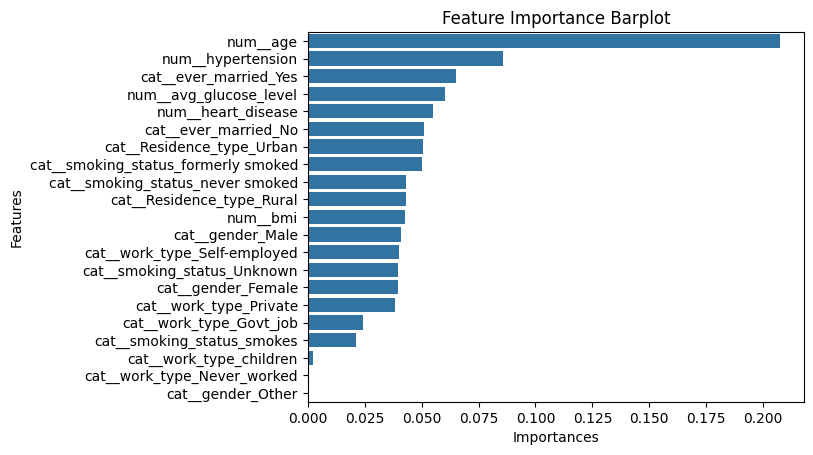

In [49]:
sns.barplot(x='Importances',y='Features',data=feature_importance_df)
plt.title("Feature Importance Barplot")
plt.show()

###ROC-AUC Score

In [50]:
from sklearn.metrics import roc_auc_score
score=roc_auc_score(y_test,y_prob)
print(score)

0.7836522633744856
